# FaceMesh para extracción de rasgos
## Captura · Face Mesh · Extraccion de Rasgos

**Pipeline:** `Webcam` → `MediaPipe Face Mesh` → `Rasgos Faciales` → `rasgos.json`

Este notebook captura el rostro, detecta los 468 landmarks faciales y extrae
los rasgos que definen la mascota. El resultado se guarda en `rasgos_checklist.json`
que usara el **Notebook 2** para generar la imagen con IA.

---
| Paso | Modulo | Output |
|------|--------|--------|
| 01 | Webcam / imagen | `frame` numpy array |
| 02 | MediaPipe Face Mesh | 468 landmarks px |
| 03 | Extractor de rasgos | diccionario de atributos |
| 04 | Guardado | `rasgos_checklist.json` |

## Instalacion de dependencias

Antes de empezar instalo las dos dependencias que faltan para el analisis facial. DeepFace es una libreria que envuelve varias redes neuronales preentrenadas para reconocimiento y analisis de rostros, y tf-keras es el backend de Keras que esas redes necesitan. Como el proyecto usa uv en lugar de pip clasico, instalo apuntando al interprete del venv. Si despues falla un import suele ser porque el kernel no recargo, ahi conviene reiniciarlo.

In [1]:
import subprocess, sys, shutil

# Este proyecto usa uv — el venv no tiene pip, hay que usar uv pip install
uv = shutil.which("uv")
if not uv:
    raise EnvironmentError(
        "uv no encontrado en PATH. Instala desde terminal:\n"
        "  uv add deepface tf-keras\n"
        "Luego reinicia el kernel."
    )

paquetes = ["deepface", "tf-keras"]
for pkg in paquetes:
    result = subprocess.run(
        [uv, "pip", "install", pkg, "--python", sys.executable, "-q"],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f"  OK: {pkg}")
    else:
        print(f"  FAIL: {pkg}")
        print(result.stderr)

print("\nPaquetes listos. Si sigue fallando 'No module named X', reinicia el kernel.")

  OK: deepface
  OK: tf-keras

Paquetes listos. Si sigue fallando 'No module named X', reinicia el kernel.


Las dos librerias instalaron sin problema. Ya tengo DeepFace y tf-keras disponibles para el paso de estimacion de emocion y edad.

## Imports

Cargo el stack de vision. OpenCV me da lectura de imagenes, webcam y operaciones de pixel, MediaPipe es el motor de deteccion de landmarks faciales, y numpy es la base para toda la geometria que calculo despues. Creo tambien la carpeta outputs donde voy guardando los resultados intermedios.

In [2]:
import cv2
import mediapipe as mp
import numpy as np
import json
import os
import time
from pathlib import Path
from IPython.display import display, Image as IPImage
from datetime import datetime

Path("outputs").mkdir(exist_ok=True)
print("Imports OK")

Imports OK


Imports OK. El entorno quedo listo para capturar y procesar el rostro.

## PASO 01 — Captura de imagen

Dos modos disponibles:
- `MODO = "webcam"`: abre ventana OpenCV. Posicionate y presiona **ESPACIO** para capturar. **Q** o **ESC** para salir sin capturar.
- `MODO = "imagen"`: carga archivo desde `RUTA_IMAGEN`.

**Nota macOS:** la ventana OpenCV debe estar en foco para que ESPACIO funcione. Si no responde, haz click sobre la ventana primero.

Marco teorico. Todo pipeline de vision arranca con la adquisicion de la imagen, que es el frame crudo en formato BGR que entrega OpenCV. Aca elijo entre dos fuentes: la webcam en vivo o un archivo de disco. Cuando uso webcam descarto los primeros frames porque el sensor necesita unos ciclos para ajustar exposicion y balance de blancos, si capturo el primer frame suele salir oscuro. En este caso uso el modo imagen con la foto agus.jpg.

La imagen es la unica entrada de todo el sistema, asi que su calidad, iluminacion y angulo condicionan todo lo que viene despues. Una cara mal iluminada o muy de perfil degrada la deteccion de landmarks y el analisis de color.

Cargando imagen: /Users/k4t3/Coding/unique-pet-generation/agus.jpg


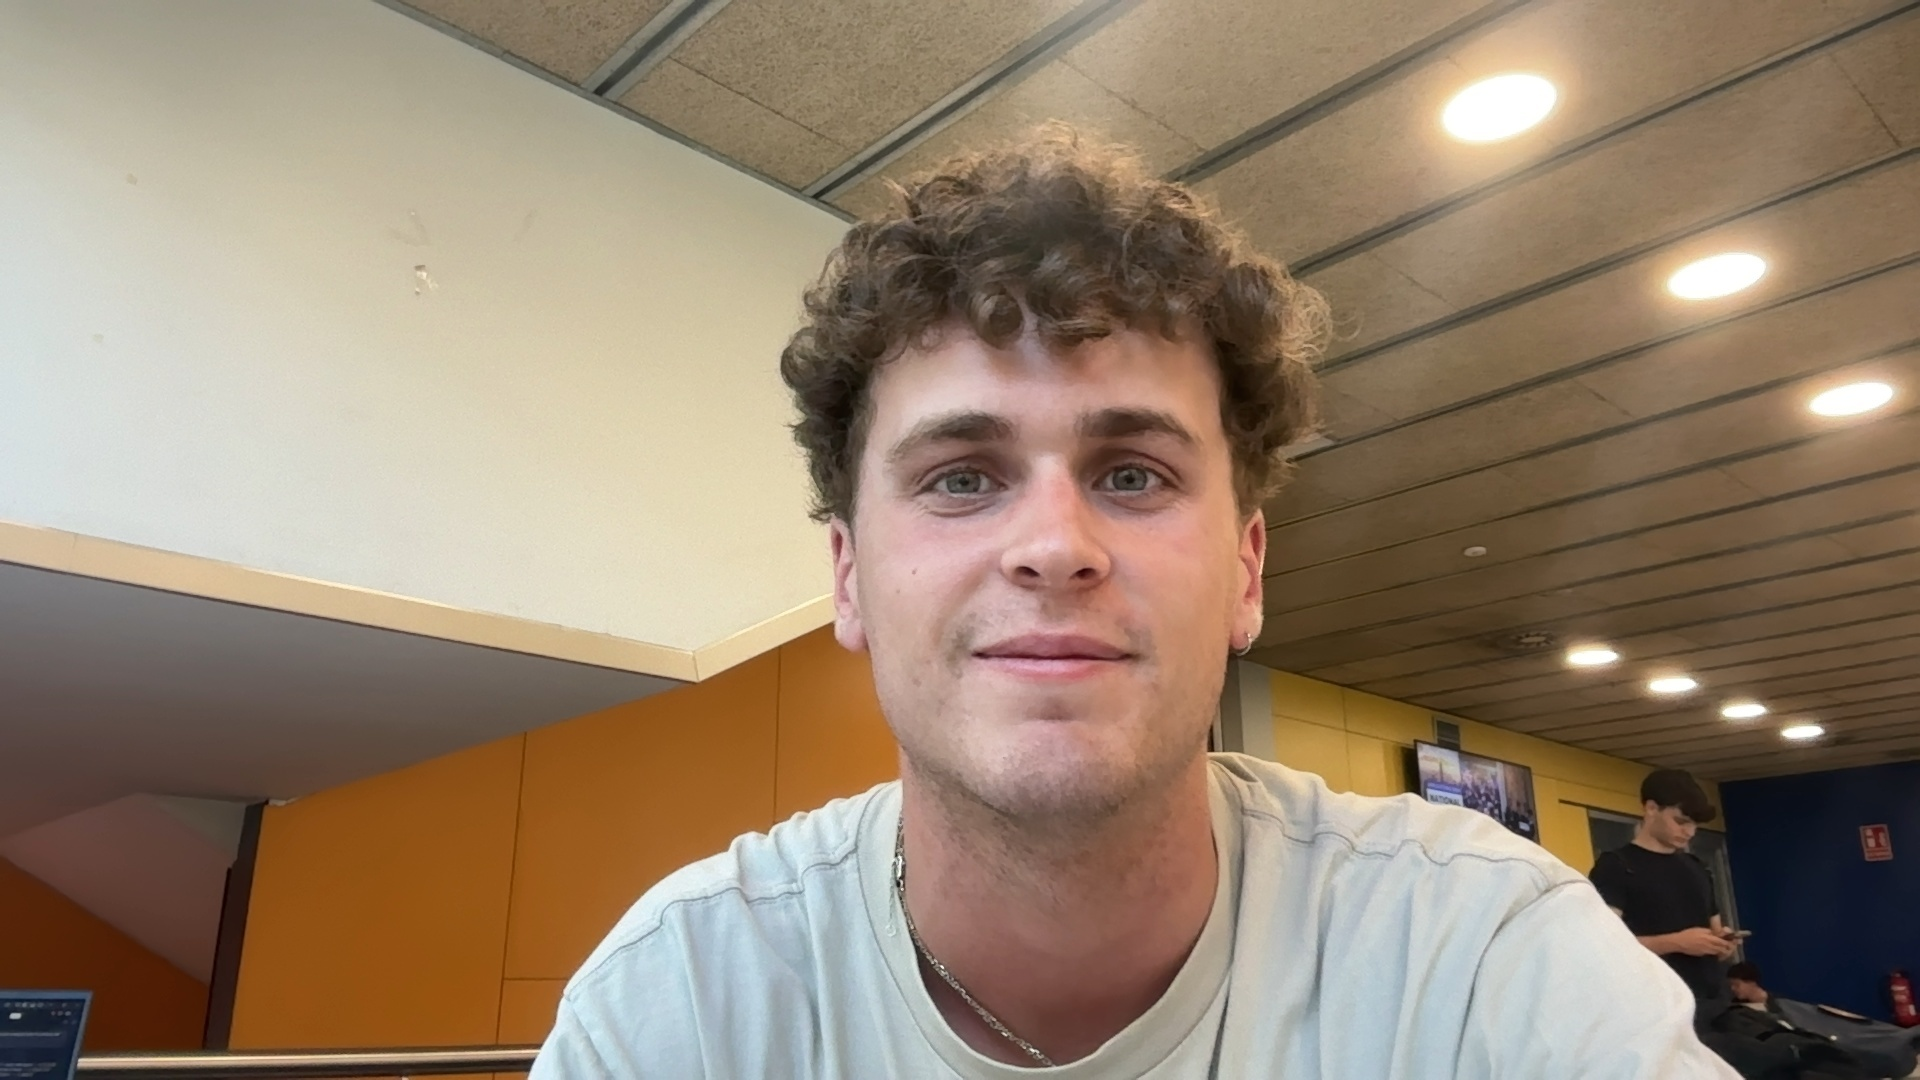

Imagen lista: 1920x1080 px


In [3]:
# ─── CONFIGURACION ───────────────────────────────
MODO = "imagen"            # "webcam" | "imagen"
RUTA_IMAGEN = "agus.jpg"   # nombre del archivo (busca en raiz del proyecto)
# ─────────────────────────────────────────────────

# Resolver ruta: el notebook corre desde notebooks/, las fotos estan en la raiz
_PROYECTO_ROOT = Path(__file__).parent.parent if "__file__" in dir() else Path.cwd().parent
RUTA_IMAGEN_RESUELTA = str(_PROYECTO_ROOT / RUTA_IMAGEN)

def capturar_webcam(guardar_en="outputs/rostro_capturado.jpg"):
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        raise RuntimeError("No se pudo abrir la webcam. Verifica que no este en uso por otra app.")

    # Calentar camara: los primeros frames suelen salir oscuros
    for _ in range(10):
        cap.read()

    print("Ventana abierta — presiona ESPACIO para capturar, Q o ESC para salir")
    print("(Haz click en la ventana si no responde al teclado)")
    frame_capturado = None

    while True:
        ret, f = cap.read()
        if not ret:
            break
        display_f = f.copy()
        cv2.putText(display_f, "ESPACIO = capturar  |  Q = salir",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.imshow("Captura de rostro", display_f)

        key = cv2.waitKey(1) & 0xFF
        if key == 32:  # ESPACIO
            frame_capturado = f.copy()
            cv2.imwrite(guardar_en, frame_capturado)
            print("Imagen capturada.")
            break
        elif key == ord('q') or key == ord('Q') or key == 27:  # Q o ESC
            print("Captura cancelada.")
            break

    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)  # fix macOS: fuerza el cierre de la ventana
    return frame_capturado

# ── Ejecutar segun modo ────────────────────────────
frame = None

if MODO == "webcam":
    frame = capturar_webcam()
else:
    print(f"Cargando imagen: {RUTA_IMAGEN_RESUELTA}")
    frame = cv2.imread(RUTA_IMAGEN_RESUELTA)
    if frame is None:
        raise FileNotFoundError(
            f"No se encontro: {RUTA_IMAGEN_RESUELTA}\n"
            f"Archivos jpg disponibles en la raiz del proyecto:\n"
            + "\n".join(str(p) for p in _PROYECTO_ROOT.glob("*.jp*g"))
        )

if frame is None:
    raise RuntimeError("No se capturo imagen. Presiona ESPACIO (no Q/ESC) o verifica la webcam.")

cv2.imwrite("outputs/rostro.jpg", frame)
display(IPImage("outputs/rostro.jpg", width=400))
print(f"Imagen lista: {frame.shape[1]}x{frame.shape[0]} px")

Cargo la foto agus.jpg y la guardo como rostro.jpg. La imagen quedo lista en su resolucion original, que es lo que voy a pasar al detector de landmarks.

## PASO 02 — Face Mesh (MediaPipe Tasks API)

MediaPipe detecta **478 landmarks** en el rostro (468 base + 10 iris con `output_face_blendshapes=False`).
Cada punto tiene coordenadas normalizadas `[0, 1]`.

Formula de conversion landmarks → pixeles:
```
px = landmark.x * width
py = landmark.y * height
```

Esta celda descarga el modelo `face_landmarker.task` (~5 MB) la primera vez.
Las versiones modernas de mediapipe (>= 0.10.14) removieron el API `mp.solutions`;
se usa el nuevo Tasks API que es el estandar actual.

Marco teorico. MediaPipe Face Mesh es un modelo de Google que predice una malla densa de 468 puntos sobre el rostro, mas 10 puntos de iris cuando se activa el refinamiento, en total 478. No detecta cajas ni recuadros sino la geometria completa de la cara: contorno, ojos, cejas, nariz, labios y mandibula. Por dentro corre en dos etapas, primero un detector de rostro liviano tipo BlazeFace y despues una red de regresion que ubica los landmarks, entrenada sobre miles de caras anotadas.

Cada landmark sale en coordenadas normalizadas entre 0 y 1 relativas al ancho y alto de la imagen, por eso los convierto a pixeles multiplicando por width y height. Trabajo con el Tasks API nuevo porque las versiones recientes de mediapipe sacaron el viejo mp.solutions. Defino un diccionario de indices con los puntos que me interesan para cada zona, asi no manejo los 478 a mano sino solo los relevantes para cada rasgo.

Modelo face_landmarker.task ya existe.


I0000 00:00:1780307156.330361   57217 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 12, prefix = pthread-default
W0000 00:00:1780307156.332565   57217 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1780307156.408705   57217 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1780307156.410408   57219 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780307156.421564   57219 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Face Mesh: 478 landmarks detectados


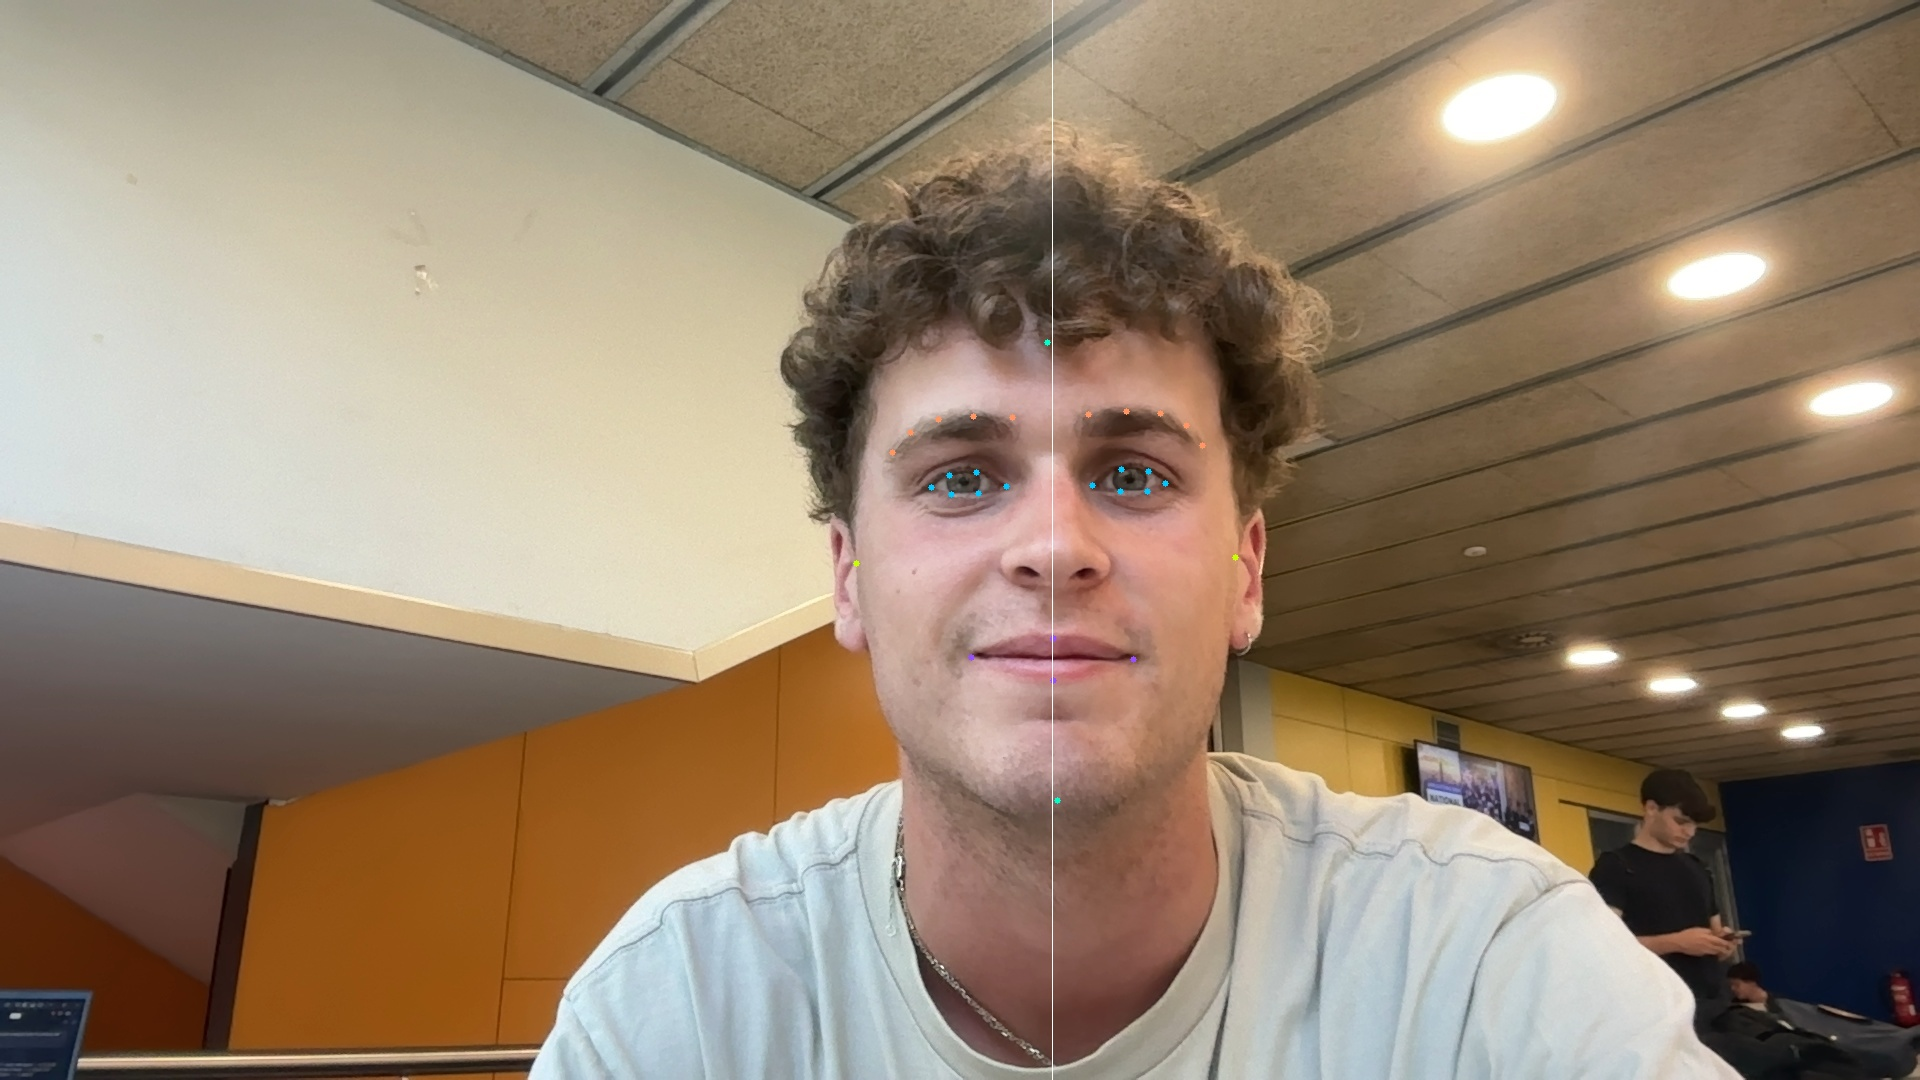

Imagen con landmarks guardada en outputs/face_mesh.jpg


In [4]:
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision as mp_vision

# Descargar modelo si no existe (~5 MB, solo la primera vez)
MODEL_PATH = "face_landmarker.task"
if not os.path.exists(MODEL_PATH):
    print("Descargando modelo face_landmarker.task (~5 MB)...")
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
    urllib.request.urlretrieve(url, MODEL_PATH)
    print("Modelo descargado.")
else:
    print("Modelo face_landmarker.task ya existe.")

INDICES = {
    "pomulo_izq": [234],
    "pomulo_der": [454],
    "frente":     [10],
    "menton":     [152],
    "ojo_izq":    [33, 160, 158, 133, 153, 144],
    "ojo_der":    [362, 385, 387, 263, 373, 380],
    "boca_ext":   [61, 291, 0, 17],
    "ceja_izq":   [70, 63, 105, 66, 107],
    "ceja_der":   [336, 296, 334, 293, 300],
}

def detectar_landmarks(frame):
    h, w = frame.shape[:2]
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    base_options = mp_tasks.BaseOptions(model_asset_path=MODEL_PATH)
    options = mp_vision.FaceLandmarkerOptions(
        base_options=base_options,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
    )

    with mp_vision.FaceLandmarker.create_from_options(options) as detector:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = detector.detect(mp_image)

    if not result.face_landmarks:
        raise ValueError("No se detecto ninguna cara. Verifica la imagen o iluminacion.")

    # Formula: x_px = lm.x * width, y_px = lm.y * height
    lms = result.face_landmarks[0]
    landmarks_px = np.array([(int(lm.x * w), int(lm.y * h)) for lm in lms], dtype=np.int32)
    print(f"Face Mesh: {len(landmarks_px)} landmarks detectados")
    return landmarks_px

def dibujar_landmarks(frame, landmarks_px, indices_dict):
    img = frame.copy()
    colores = {
        "pomulo_izq": (0,255,200), "pomulo_der": (0,255,200),
        "ojo_izq":    (255,200,0), "ojo_der":    (255,200,0),
        "boca_ext":   (255,80,150),
        "ceja_izq":   (100,150,255), "ceja_der": (100,150,255),
        "frente":     (200,255,0),   "menton":   (200,255,0),
    }
    for zona, idxs in indices_dict.items():
        color = colores.get(zona, (255,255,255))
        for idx in idxs:
            px, py = landmarks_px[idx]
            cv2.circle(img, (px, py), 3, color, -1)
    cx = int(landmarks_px[[10,152]].mean(axis=0)[0])
    cv2.line(img, (cx, 0), (cx, frame.shape[0]), (255,255,255), 1)
    return img

landmarks_px = detectar_landmarks(frame)
img_mesh = dibujar_landmarks(frame, landmarks_px, INDICES)
cv2.imwrite("outputs/face_mesh.jpg", img_mesh)
display(IPImage("outputs/face_mesh.jpg", width=500))
print("Imagen con landmarks guardada en outputs/face_mesh.jpg")

El detector encontro los 478 landmarks de la cara y dibuje encima los puntos de pomulos, ojos, cejas, boca, frente y menton, mas la linea del eje central vertical. Con la malla detectada ya tengo toda la geometria que necesito para derivar los rasgos.

## PASO 03a — Rasgos Geometricos (de landmarks)

Calculamos ratios y proporciones a partir de las coordenadas de los landmarks.
Todas las medidas son relativas (normalizadas por anchura de cara) para ser
invariantes al tamano de la imagen y la distancia a la camara.

Marco teorico. Aca aplico morfometria geometrica: en lugar de pedirle a una red que clasifique, calculo proporciones entre landmarks y las traduzco a categorias con umbrales. La clave es que todas las medidas son relativas, las normalizo por el ancho de la cara, asi son invariantes a la escala y a la distancia a la camara. Una cara cerca o lejos da el mismo ratio.

Calculo siete rasgos. La forma de cara sale del cociente entre el ancho de pomulos y el alto de frente a menton. El tamano de ojos sale de la apertura vertical del parpado sobre el ancho de cara. La sonrisa mide cuanto suben las comisuras respecto al labio inferior, recordando que en coordenadas de imagen el eje vertical crece hacia abajo. Las cejas miden la curvatura del punto central contra los extremos. La simetria compara cada landmark con el reflejo esperado de su par espejado respecto al eje central. El tono de piel muestrea parches en frente y mejillas y promedia luminosidad. El color de ojos muestrea el iris en espacio HSV y clasifica por matiz, saturacion y valor, usando la mediana en lugar de la media porque es robusta frente a pixeles de parpado o reflejos.

In [5]:
# Formula forma de cara:
#   ratio = dist(pomulo_izq, pomulo_der) / dist(frente, menton)
#   ratio < 0.55  → larga   |  0.55-0.65 → ovalada  |  0.65-0.75 → corazon
#   0.75-0.85 → redonda  |  > 0.85 → cuadrada
def calcular_forma_cara(lm):
    anchura = float(np.linalg.norm(lm[454] - lm[234]))
    altura  = float(np.linalg.norm(lm[152] - lm[10]))
    ratio   = anchura / altura if altura > 0 else 0.6
    if   ratio < 0.55: forma = "larga"
    elif ratio < 0.65: forma = "ovalada"
    elif ratio < 0.75: forma = "corazon"
    elif ratio < 0.85: forma = "redonda"
    else:              forma = "cuadrada"
    return forma, round(ratio, 3)

# Formula ojos:
#   apertura_ojo = dist(parpado_superior, parpado_inferior)  [pts[1] y pts[5] del grupo de 6]
#   ratio_ojo = promedio(apertura_izq, apertura_der) / anchura_cara
#   < 0.06 → pequenos  |  0.06-0.10 → medianos  |  > 0.10 → grandes
def calcular_ojos(lm):
    def apertura(idxs):
        pts = lm[idxs]
        return float(np.linalg.norm(pts[1] - pts[5]))
    ap = (apertura(INDICES["ojo_izq"]) + apertura(INDICES["ojo_der"])) / 2
    anchura_cara = float(np.linalg.norm(lm[454] - lm[234]))
    ratio = ap / anchura_cara if anchura_cara > 0 else 0.08
    if   ratio < 0.06: tamano = "pequenos"
    elif ratio < 0.10: tamano = "medianos"
    else:              tamano = "grandes"
    c_izq = lm[INDICES["ojo_izq"]].mean(axis=0)
    c_der = lm[INDICES["ojo_der"]].mean(axis=0)
    dist_rel = round(float(np.linalg.norm(c_der - c_izq)) / anchura_cara, 3)
    return tamano, dist_rel

# Formula sonrisa:
#   score = clip( (y_labio_inf - media(y_comisuras)) / 20 , 0, 1 )
#   En coordenadas imagen y crece hacia abajo, asi que si las comisuras
#   estan mas arriba que el labio inferior, el valor es positivo (sonrisa).
def calcular_sonrisa(lm):
    comisura_izq = lm[61]
    comisura_der = lm[291]
    labio_inf    = lm[17]
    altura = float(labio_inf[1] - (comisura_izq[1] + comisura_der[1]) / 2)
    return round(float(np.clip(altura / 20, 0, 1)), 3)

# Formula cejas:
#   curvatura = y_punto_central_ceja - media(y_extremo_izq, y_extremo_der)
#   Negativo → ceja arqueada hacia arriba  |  positivo → ceja caida  |  ~0 → recta
def calcular_cejas(lm):
    ceja = lm[INDICES["ceja_izq"]]
    curv = ceja[2][1] - (ceja[0][1] + ceja[4][1]) / 2
    if   curv < -3: return "arqueadas"
    elif curv >  3: return "rectas"
    else:           return "finas"

# Formula simetria:
#   Para cada par de landmarks espejados (i, d), calcula el error de simetria:
#   error = dist(landmark_der, reflejo_esperado_de_landmark_izq)
#   reflejo_x = 2 * eje_central - x_izq
#   simetria = clip(1 - mean(errores) / 50, 0, 1)
def calcular_simetria(lm, w):
    eje = w / 2
    pares = [(33, 263), (70, 300), (61, 291), (234, 454)]
    errores = [np.linalg.norm(lm[d] - np.array([2*eje - lm[i][0], lm[i][1]])) for i, d in pares]
    return round(float(max(0, 1 - np.mean(errores) / 50)), 3)

# Formula tono de piel:
#   Muestrea parches de 16x16 px alrededor de frente y mejillas (landmarks 10, 234, 454)
#   luminosidad = media de todos los valores de pixel (BGR, no convertido a gris)
#   > 180 → claro  |  140-180 → medio  |  100-140 → oscuro  |  < 100 → muy_oscuro
def calcular_tono_piel(frame, lm):
    h, w = frame.shape[:2]
    muestras = []
    for idx in [10, 234, 454]:
        cx, cy = int(lm[idx][0]), int(lm[idx][1])
        patch = frame[max(0,cy-8):min(h,cy+8), max(0,cx-8):min(w,cx+8)]
        if patch.size > 0:
            muestras.append(float(patch.mean()))
    lum = np.mean(muestras) if muestras else 128
    if   lum > 180: return "claro"
    elif lum > 140: return "medio"
    elif lum > 100: return "oscuro"
    else:           return "muy_oscuro"

# Formula color de ojos:
#   Iris landmarks: 468 (centro iris izq), 473 (centro iris der)
#   — disponibles porque face_landmarker.task retorna 478 puntos (468 mesh + 10 iris)
#   1. Muestrear parche 10x10 px centrado en cada iris
#   2. Calcular mediana HSV del parche (mediana es robusta frente a pixels de parpado)
#   3. Clasificar por hue, saturation, value:
#      V < 50          → negro
#      S < 40          → gris
#      V < 80          → marron_oscuro
#      H < 15 o H>160  → marron   (tonos rojizos-marrones)
#      H 15-35         → avellana
#      H 35-85         → verde
#      H 85-130        → azul
#      resto           → marron
#   OpenCV HSV: H en [0,179], S en [0,255], V en [0,255]
def calcular_color_ojos(frame, lm):
    if len(lm) < 474:
        return "desconocido"  # modelo sin iris landmarks

    h_img, w_img = frame.shape[:2]
    muestras_hsv = []

    for iris_idx in [468, 473]:
        cx, cy = int(lm[iris_idx][0]), int(lm[iris_idx][1])
        patch = frame[max(0, cy-5):min(h_img, cy+5), max(0, cx-5):min(w_img, cx+5)]
        if patch.size == 0:
            continue
        hsv = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
        mediana = np.median(hsv.reshape(-1, 3), axis=0)
        muestras_hsv.append(mediana)

    if not muestras_hsv:
        return "desconocido"

    h_val, s_val, v_val = np.mean(muestras_hsv, axis=0)

    if v_val < 50:                          return "negro"
    if s_val < 40:                          return "gris"
    if v_val < 80:                          return "marron_oscuro"
    if h_val < 15 or h_val > 160:          return "marron"
    if 15 <= h_val < 35:                    return "avellana"
    if 35 <= h_val < 85:                    return "verde"
    if 85 <= h_val < 130:                   return "azul"
    return "marron"

# ── Ejecutar calculos ─────────────────────────────
h, w = frame.shape[:2]
forma_cara, proporcion   = calcular_forma_cara(landmarks_px)
ojos_tamano, dist_ojos   = calcular_ojos(landmarks_px)
sonrisa_score            = calcular_sonrisa(landmarks_px)
cejas                    = calcular_cejas(landmarks_px)
simetria                 = calcular_simetria(landmarks_px, w)
tono_piel                = calcular_tono_piel(frame, landmarks_px)
color_ojos               = calcular_color_ojos(frame, landmarks_px)

print("Rasgos geometricos calculados:")
print(f"  Forma cara:    {forma_cara}  (ratio={proporcion})")
print(f"  Ojos:          {ojos_tamano}  (dist_relativa={dist_ojos})")
print(f"  Color ojos:    {color_ojos}")
print(f"  Sonrisa score: {sonrisa_score}  (0=neutro, 1=amplia)")
print(f"  Cejas:         {cejas}")
print(f"  Simetria:      {simetria}  (1=perfecta)")
print(f"  Tono de piel:  {tono_piel}")

Rasgos geometricos calculados:
  Forma cara:    redonda  (ratio=0.827)
  Ojos:          pequenos  (dist_relativa=0.441)
  Color ojos:    negro
  Sonrisa score: 1.0  (0=neutro, 1=amplia)
  Cejas:         arqueadas
  Simetria:      0.0  (1=perfecta)
  Tono de piel:  oscuro


Los rasgos salieron asi: forma de cara redonda con ratio 0.827, ojos pequenos, color de ojos negro, sonrisa 1.0, cejas arqueadas, simetria 0.0 y tono de piel oscuro. Dos resultados me hacen ruido y conviene anotarlos. La simetria dio 0.0, que es el piso, lo que indica que la cara no esta centrada ni frontal respecto al eje vertical que asume la formula, probablemente por el angulo de la foto. Y el tono de piel sale de luminosidad cruda, asi que una foto con poca luz lo empuja hacia oscuro aunque la piel no lo sea. Son las limitaciones tipicas de un metodo geometrico con umbrales fijos: rapido y explicable, pero sensible al encuadre y a la iluminacion.

## PASO 03b — Analisis con DeepFace

DeepFace ejecuta una red neuronal pre-entrenada para estimar **emocion dominante** y **edad**.
Internamente usa modelos basados en VGG-Face y mini-Xception.
`enforce_detection=False` permite continuar aunque la deteccion de cara no sea perfecta.

Marco teorico. DeepFace complementa lo geometrico con redes neuronales preentrenadas. Para emocion usa una red liviana tipo mini Xception entrenada sobre FER, que clasifica entre siete emociones basicas, y para edad usa una red basada en VGG-Face que estima la edad como regresion. A diferencia de mis ratios, esto aprende patrones de textura y forma directamente de los pixeles. Pongo enforce_detection en False para que no se caiga si la deteccion interna de cara no es perfecta, ya que prefiero un resultado aproximado a una excepcion que corta el pipeline.

In [6]:
from deepface import DeepFace

def analizar_deepface(frame):
    try:
        resultado = DeepFace.analyze(
            frame,
            actions=["emotion", "age"],
            enforce_detection=False,
            silent=True,
        )
        if isinstance(resultado, list):
            resultado = resultado[0]
        emociones  = resultado.get("emotion", {})
        expresion  = resultado.get("dominant_emotion", "neutral")
        confianza  = round(emociones.get(expresion, 0) / 100.0, 3)
        edad       = int(resultado.get("age", 25))
        return expresion, confianza, edad, emociones
    except Exception as e:
        print(f"DeepFace error: {e} — usando valores neutros")
        return "neutral", 0.5, 25, {}

expresion, confianza, edad, todas_emociones = analizar_deepface(frame)

print("DeepFace:")
print(f"  Expresion:  {expresion}  ({confianza:.0%} confianza)")
print(f"  Edad est.:  ~{edad} anios")
print("  Todas las emociones detectadas:")
for em, score in sorted(todas_emociones.items(), key=lambda x: -x[1]):
    barra = "|" * int(score / 5)
    print(f"    {em:<12} {barra} {score:.1f}%")

DeepFace:
  Expresion:  neutral  (67% confianza)
  Edad est.:  ~23 anios
  Todas las emociones detectadas:
    neutral      ||||||||||||| 67.0%
    happy        |||||| 30.2%
    sad           2.7%
    fear          0.1%
    angry         0.0%
    surprise      0.0%
    disgust       0.0%


DeepFace estimo expresion neutral con 67 por ciento de confianza y una edad de 23 anios. El desglose de emociones es coherente: neutral 67 y happy 30 se reparten casi todo, el resto es ruido. Es interesante el contraste con mi calculo geometrico de sonrisa que dio 1.0: la boca esta abierta o las comisuras altas, pero la red lee la expresion global como neutral. Son dos senales distintas que despues combino en el prompt.

## PASO 03c — Construccion de Prompt Tokens

Traduccion de rasgos numericos a lenguaje natural para Stable Diffusion.
Cada rasgo se mapea a un fragmento de texto descriptivo que el modelo generativo
puede interpretar directamente como condicion de generacion.

Marco teorico. Los modelos generativos de imagen tipo Stable Diffusion se condicionan con texto a traves de un encoder CLIP que convierte cada palabra en un vector. Por eso no le paso numeros ni categorias en espanol sino frases descriptivas en ingles, que es el dominio donde esos modelos fueron entrenados y donde responden mejor. Cada rasgo se mapea a un fragmento de prompt mediante diccionarios fijos, una decision de diseno que me da control total sobre como se traduce cada categoria. Filtro los tokens vacios para no ensuciar el prompt final.

In [7]:
FORMA_CARA_MAP = {
    "ovalada":  "with a soft oval face",
    "redonda":  "with chubby round face, chubby cheeks",
    "cuadrada": "with a strong square jawline",
    "corazon":  "with heart-shaped face, wide forehead",
    "larga":    "with an elongated face",
}
OJOS_MAP = {
    "grandes":  "with big round expressive eyes",
    "medianos": "with almond-shaped eyes",
    "pequenos": "with narrow sleepy eyes",
}
COLOR_OJOS_MAP = {
    "negro":         "with deep black eyes",
    "marron_oscuro": "with dark brown eyes",
    "marron":        "with warm brown eyes",
    "avellana":      "with hazel eyes",
    "verde":         "with bright green eyes",
    "azul":          "with blue eyes",
    "gris":          "with gray eyes",
    "desconocido":   "",
}
EXPRESION_MAP = {
    "happy":    "cheerful happy expression, smiling warmly",
    "sad":      "melancholic gentle expression",
    "surprised":"wide-eyed surprised expression",
    "neutral":  "calm serene expression",
    "angry":    "determined fierce expression",
    "fear":     "shy timid expression",
    "disgust":  "grumpy pouty expression",
}
TONO_MAP = {
    "claro":      "cream white fur with golden highlights",
    "medio":      "warm golden brown fur",
    "oscuro":     "deep chocolate brown fur with amber accents",
    "muy_oscuro": "dark charcoal fur with blue-black sheen",
}
CEJAS_MAP = {
    "arqueadas": "with expressive arched eyebrows",
    "rectas":    "with straight bold eyebrows",
    "finas":     "with delicate thin eyebrows",
}

prompt_tokens = [
    FORMA_CARA_MAP.get(forma_cara, ""),
    OJOS_MAP.get(ojos_tamano, ""),
    COLOR_OJOS_MAP.get(color_ojos, ""),
    EXPRESION_MAP.get(expresion, ""),
    TONO_MAP.get(tono_piel, ""),
    CEJAS_MAP.get(cejas, ""),
]
prompt_tokens = [t for t in prompt_tokens if t]

print("Prompt tokens generados:")
for i, token in enumerate(prompt_tokens, 1):
    print(f"  {i}. {token}")

Prompt tokens generados:
  1. with chubby round face, chubby cheeks
  2. with narrow sleepy eyes
  3. with deep black eyes
  4. calm serene expression
  5. deep chocolate brown fur with amber accents
  6. with expressive arched eyebrows


Quedaron seis tokens, uno por rasgo con valor util. Cara redonda se volvio chubby round face, ojos pequenos narrow sleepy eyes, color negro deep black eyes, expresion neutral calm serene expression, tono oscuro chocolate brown fur y cejas arqueadas arched eyebrows. Notar que el tono de piel ya se traduce directo a color de pelaje, que es el puente conceptual entre la cara humana y la mascota.

## PASO 04 — Guardar Checklist en JSON

`rasgos_checklist.json` es el output final de este notebook y el input del Notebook 2.

Estructura de cada rasgo:
- `valor`: dato extraido
- `confianza`: fiabilidad de la medicion
- `prompt_token`: traduccion al prompt de Stable Diffusion
- `verificado`: flag editable antes de pasar al NB2

Marco teorico. Este paso materializa el contrato entre los dos notebooks. Guardo un JSON estructurado donde cada rasgo lleva no solo su valor sino tambien su confianza, su traduccion a prompt y un flag de verificado que puedo editar a mano antes de generar. Separar la extraccion de la generacion en dos etapas con un archivo intermedio me deja inspeccionar y corregir los rasgos sin volver a correr la deteccion, que es buena practica en cualquier pipeline.

In [8]:
checklist = {
    "metadata": {
        "timestamp":     datetime.now().isoformat(),
        "imagen_origen": "webcam" if MODO == "webcam" else RUTA_IMAGEN,
        "version":       "1.0",
    },
    "rasgos_geometricos": {
        "forma_cara": {
            "valor":        forma_cara,
            "proporcion":   proporcion,
            "confianza":    "alta",
            "prompt_token": FORMA_CARA_MAP.get(forma_cara, ""),
            "verificado":   True,
        },
        "ojos": {
            "tamano":        ojos_tamano,
            "dist_relativa": dist_ojos,
            "confianza":     "alta",
            "prompt_token":  OJOS_MAP.get(ojos_tamano, ""),
            "verificado":    True,
        },
        "color_ojos": {
            "valor":        color_ojos,
            "confianza":    "media",
            "prompt_token": COLOR_OJOS_MAP.get(color_ojos, ""),
            "verificado":   True,
        },
        "cejas": {
            "tipo":          cejas,
            "confianza":     "media",
            "prompt_token":  CEJAS_MAP.get(cejas, ""),
            "verificado":    True,
        },
        "sonrisa": {
            "score":         sonrisa_score,
            "interpretacion":"amplia" if sonrisa_score > 0.6 else "leve" if sonrisa_score > 0.3 else "neutra",
            "confianza":     "media",
            "verificado":    True,
        },
        "simetria": {
            "score":         simetria,
            "interpretacion":"alta" if simetria > 0.8 else "media" if simetria > 0.6 else "baja",
            "confianza":     "alta",
            "verificado":    True,
        },
    },
    "rasgos_deepface": {
        "expresion": {
            "valor":         expresion,
            "confianza":     confianza,
            "todas":         todas_emociones,
            "prompt_token":  EXPRESION_MAP.get(expresion, ""),
            "verificado":    True,
        },
        "edad_estimada": {
            "valor":         edad,
            "confianza":     "media",
            "verificado":    True,
        },
    },
    "tono_piel": {
        "valor":        tono_piel,
        "confianza":    "media",
        "prompt_token": TONO_MAP.get(tono_piel, ""),
        "verificado":   True,
    },
    "prompt_tokens": {
        "lista":    prompt_tokens,
        "completo": ", ".join(prompt_tokens),
    },
}

ruta_json = "outputs/rasgos_checklist.json"
with open(ruta_json, "w", encoding="utf-8") as f:
    json.dump(checklist, f, ensure_ascii=False, indent=2)

print(f"Checklist guardado en: {ruta_json}")
print()
print(json.dumps(checklist, ensure_ascii=False, indent=2))

Checklist guardado en: outputs/rasgos_checklist.json

{
  "metadata": {
    "timestamp": "2026-06-01T11:45:58.705447",
    "imagen_origen": "agus.jpg",
    "version": "1.0"
  },
  "rasgos_geometricos": {
    "forma_cara": {
      "valor": "redonda",
      "proporcion": 0.827,
      "confianza": "alta",
      "prompt_token": "with chubby round face, chubby cheeks",
      "verificado": true
    },
    "ojos": {
      "tamano": "pequenos",
      "dist_relativa": 0.441,
      "confianza": "alta",
      "prompt_token": "with narrow sleepy eyes",
      "verificado": true
    },
    "color_ojos": {
      "valor": "negro",
      "confianza": "media",
      "prompt_token": "with deep black eyes",
      "verificado": true
    },
    "cejas": {
      "tipo": "arqueadas",
      "confianza": "media",
      "prompt_token": "with expressive arched eyebrows",
      "verificado": true
    },
    "sonrisa": {
      "score": 1.0,
      "interpretacion": "amplia",
      "confianza": "media",
      "verifi

El checklist quedo guardado en outputs/rasgos_checklist.json con timestamp, los rasgos geometricos, los de DeepFace, el tono de piel y el prompt completo concatenado. Ese string completo es lo que el Notebook 2 le pasa al generador. El archivo deja todo trazable: puedo ver de donde salio cada token del prompt.

## Resumen visual del checklist

Imprimo un resumen legible del checklist para revisar de un vistazo todos los rasgos con su confianza antes de pasar al Notebook 2. Es un control de calidad manual: si algun rasgo salio raro, como la simetria en 0.0, lo detecto aca antes de gastar computo en la generacion.

In [9]:
print("=" * 64)
print("         CHECKLIST DE RASGOS — LISTO PARA NB2")
print("=" * 64)

items = [
    ("Forma cara",    forma_cara,    checklist["rasgos_geometricos"]["forma_cara"]["confianza"]),
    ("Tamano ojos",   ojos_tamano,   checklist["rasgos_geometricos"]["ojos"]["confianza"]),
    ("Color ojos",    color_ojos,    checklist["rasgos_geometricos"]["color_ojos"]["confianza"]),
    ("Cejas",         cejas,         checklist["rasgos_geometricos"]["cejas"]["confianza"]),
    ("Sonrisa",       f"{sonrisa_score:.2f}",  checklist["rasgos_geometricos"]["sonrisa"]["confianza"]),
    ("Simetria",      f"{simetria:.2f}",       checklist["rasgos_geometricos"]["simetria"]["confianza"]),
    ("Expresion",     expresion,     f"{confianza:.0%}"),
    ("Edad est.",     f"~{edad} anios", "media"),
    ("Tono piel",     tono_piel,     checklist["tono_piel"]["confianza"]),
]

for nombre, valor, conf in items:
    print(f"  [OK]  {nombre:<15} {valor:<18} confianza: {conf}")

print("-" * 64)
print("  PROMPT TOKENS GENERADOS:")
for t in prompt_tokens:
    print(f"    > {t}")
print("-" * 64)
print("  OUTPUT: outputs/rasgos_checklist.json")
print("  Siguiente paso: Notebook 2 — Generacion de Mascota")
print("=" * 64)

         CHECKLIST DE RASGOS — LISTO PARA NB2
  [OK]  Forma cara      redonda            confianza: alta
  [OK]  Tamano ojos     pequenos           confianza: alta
  [OK]  Color ojos      negro              confianza: media
  [OK]  Cejas           arqueadas          confianza: media
  [OK]  Sonrisa         1.00               confianza: media
  [OK]  Simetria        0.00               confianza: alta
  [OK]  Expresion       neutral            confianza: 67%
  [OK]  Edad est.       ~23 anios          confianza: media
  [OK]  Tono piel       oscuro             confianza: media
----------------------------------------------------------------
  PROMPT TOKENS GENERADOS:
    > with chubby round face, chubby cheeks
    > with narrow sleepy eyes
    > with deep black eyes
    > calm serene expression
    > deep chocolate brown fur with amber accents
    > with expressive arched eyebrows
----------------------------------------------------------------
  OUTPUT: outputs/rasgos_checklist.json
  Si

El resumen confirma los nueve rasgos y los seis tokens del prompt. Mirando las confianzas, forma de cara, ojos y simetria son altas por geometria, mientras que color de ojos, cejas, tono y edad quedan en media. La simetria en 0.0 es la senal a revisar: conviene recapturar con la cara mas frontal si quiero ese rasgo confiable. Con el checklist validado cierro el Notebook 1 y queda listo el input para la generacion de la mascota.